In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os, glob

PROJECT_DIR = "/content/drive/MyDrive/Insider-Market Trend Co-relation with ML"
print("PROJECT_DIR exists?", os.path.exists(PROJECT_DIR))
print("Listing PROJECT_DIR:")
print(sorted(os.listdir(PROJECT_DIR))[:50])

print("\nSearching for jpm_prices_clean.csv anywhere under PROJECT_DIR...")
hits = glob.glob(PROJECT_DIR + "/**/jpm_prices_clean.csv", recursive=True)
print("Found:", hits)

print("\nSearching for jpm_insider_clean.csv anywhere under PROJECT_DIR...")
hits2 = glob.glob(PROJECT_DIR + "/**/jpm_insider_clean.csv", recursive=True)
print("Found:", hits2)

PROJECT_DIR exists? True
Listing PROJECT_DIR:
['eda_outputs']

Searching for jpm_prices_clean.csv anywhere under PROJECT_DIR...
Found: []

Searching for jpm_insider_clean.csv anywhere under PROJECT_DIR...
Found: []


In [6]:
import os
import pandas as pd

# Use your exact base (note the space before the slash is included exactly as you wrote it)
BASE_DIR = "/content/drive/MyDrive/Insider-Market Trend Co-relation with ML /cleaned & processed/processed"

PRICE_CSV  = os.path.join(BASE_DIR, "jpm_prices_clean.csv")
INSIDER_CSV = os.path.join(BASE_DIR, "jpm_insider_clean.csv")

print("PRICE_CSV :", PRICE_CSV)
print("INSIDER_CSV:", INSIDER_CSV)

assert os.path.exists(PRICE_CSV), f"Missing: {PRICE_CSV}"
assert os.path.exists(INSIDER_CSV), f"Missing: {INSIDER_CSV}"

px = pd.read_csv(PRICE_CSV)
ins = pd.read_csv(INSIDER_CSV)

print("✅ Loaded prices:", px.shape)
print("✅ Loaded insider:", ins.shape)

display(px.head(3))
display(ins.head(3))

PRICE_CSV : /content/drive/MyDrive/Insider-Market Trend Co-relation with ML /cleaned & processed/processed/jpm_prices_clean.csv
INSIDER_CSV: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML /cleaned & processed/processed/jpm_insider_clean.csv
✅ Loaded prices: (2805, 11)
✅ Loaded insider: (1000, 19)


,date,price,open,high,low,vol.,change_%,volume,date_ddmmyyyy,ret_close,ret_reported
0,2015-01-02,62.49,62.62,62.96,62.07,12.60M,-0.0014,12600000.0,02/01/2015,NaN,-0.0014
1,2015-01-05,60.55,62.06,62.28,60.23,20.10M,-0.0310,20100000.0,05/01/2015,-0.031045,-0.0310
2,2015-01-06,58.98,60.64,60.75,58.35,29.07M,-0.0259,29070000.0,06/01/2015,-0.025929,-0.0259


,unnamed:_0,filing_date,trade_date,ticker,insider_name,insider_title,trade_type,price,qty,owned,δown%,value,trade_price,trade_value,delta_own_pct,trade_date_ddmmyyyy,filing_date_ddmmyyyy,calc_value,value_abs_diff
0,NaN,2026-02-19 17:36:59,2026-02-19,JPM,Leopold Robin,Head of HR,S,$307.14,-432.0,83755.0,-0.01,"-$132,684",307.14,-132684.0,-0.0001,19/02/2026,19/02/2026,-132684.48,0.48
1,NaN,2026-02-19 17:33:57,2026-02-19,JPM,Rohrbaugh Troy L,Co-CEO CIB,S,$307.11,-50000.0,111371.0,-0.31,"-$15,355,670",307.11,-15355670.0,-0.0031,19/02/2026,19/02/2026,-15355500.00,170.00
2,NaN,2026-02-19 17:19:53,2026-02-19,JPM,Dimon James,"COB, CEO",S,$307.19,-69512.0,6275645.0,-0.01,"-$21,353,561",307.19,-21353561.0,-0.0001,19/02/2026,19/02/2026,-21353391.28,169.72


In [7]:
px["date"] = pd.to_datetime(px["date"], errors="coerce")
ins["trade_date"] = pd.to_datetime(ins["trade_date"], errors="coerce")
ins["filing_date"] = pd.to_datetime(ins["filing_date"], errors="coerce")

assert px["date"].isna().sum() == 0, "px.date has NaT"
assert ins["trade_date"].isna().sum() == 0, "ins.trade_date has NaT"
assert ins["filing_date"].isna().sum() == 0, "ins.filing_date has NaT"

px = px.sort_values("date").reset_index(drop=True)

print("Price range:", px["date"].min(), "→", px["date"].max())
print("Filing range:", ins["filing_date"].min(), "→", ins["filing_date"].max())

Price range: 2015-01-02 00:00:00 → 2026-02-27 00:00:00
Filing range: 2015-01-05 17:27:14 → 2026-02-19 17:36:59


In [8]:
# 1) Weekend rows should be 0 for trading days
weekend_rows = (px["date"].dt.weekday >= 5).sum()
print("Weekend rows (should be 0):", weekend_rows)
assert weekend_rows == 0, "Your trading calendar contains weekend dates."

# 2) Must be strictly increasing after sort
assert px["date"].is_monotonic_increasing, "px.date is not sorted increasing."

# 3) Expected columns
need_cols = ["open", "high", "low", "price", "volume"]
for c in need_cols:
    assert c in px.columns, f"Missing price column: {c}"

for c in ["ticker","insider_name","insider_title","trade_type","trade_value","qty"]:
    assert c in ins.columns, f"Missing insider column: {c}"

print("✅ QA checks passed.")

Weekend rows (should be 0): 0
✅ QA checks passed.


In [9]:
trading_days = pd.to_datetime(sorted(px["date"].dt.normalize().unique()))
assert len(trading_days) == len(px), "Expected one row per trading day in px."

def next_trading_day_on_or_after(d):
    d = pd.Timestamp(d).normalize()
    i = np.searchsorted(trading_days, d, side="left")
    return pd.NaT if i >= len(trading_days) else pd.Timestamp(trading_days[i])

def next_trading_day_after(d):
    d = pd.Timestamp(d).normalize()
    i = np.searchsorted(trading_days, d, side="right")
    return pd.NaT if i >= len(trading_days) else pd.Timestamp(trading_days[i])

print("Trading days:", len(trading_days))
print("First:", trading_days[0], "Last:", trading_days[-1])

Trading days: 2805
First: 2015-01-02 00:00:00 Last: 2026-02-27 00:00:00


In [10]:
ins = ins.copy()

# Clean strings (prevents silent category mismatch bugs)
for c in ["ticker","insider_name","insider_title","trade_type"]:
    ins[c] = ins[c].astype(str).str.strip()

ins["filing_day"] = ins["filing_date"].dt.normalize()
ins["trade_day"]  = ins["trade_date"].dt.normalize()
ins["filing_minutes"] = ins["filing_date"].dt.hour * 60 + ins["filing_date"].dt.minute

AFTER_CLOSE_MINUTES = 16 * 60  # 16:00

ins["event_day"] = np.where(
    ins["filing_minutes"] >= AFTER_CLOSE_MINUTES,
    ins["filing_day"].apply(next_trading_day_after),
    ins["filing_day"].apply(next_trading_day_on_or_after),
)

# Portfolio-grade asserts
assert ins["event_day"].isna().sum() == 0, "Some event_day are NaT."
assert set(ins["event_day"]).issubset(set(trading_days)), "event_day contains non-trading days."

print("Percent filings after close:", (ins["filing_minutes"] >= AFTER_CLOSE_MINUTES).mean())
display(ins[["filing_date","filing_minutes","filing_day","event_day"]].head(10))

Percent filings after close: 0.978


,filing_date,filing_minutes,filing_day,event_day
0,2026-02-19 17:36:59,1056,2026-02-19,2026-02-20
1,2026-02-19 17:33:57,1053,2026-02-19,2026-02-20
2,2026-02-19 17:19:53,1039,2026-02-19,2026-02-20
3,2026-02-17 17:21:20,1041,2026-02-17,2026-02-18
4,2026-02-17 17:21:19,1041,2026-02-17,2026-02-18
5,2026-02-17 17:21:18,1041,2026-02-17,2026-02-18
6,2026-02-17 17:21:16,1041,2026-02-17,2026-02-18
7,2026-02-17 17:21:15,1041,2026-02-17,2026-02-18
8,2026-02-17 17:21:12,1041,2026-02-17,2026-02-18
9,2026-02-04 16:18:21,978,2026-02-04,2026-02-05


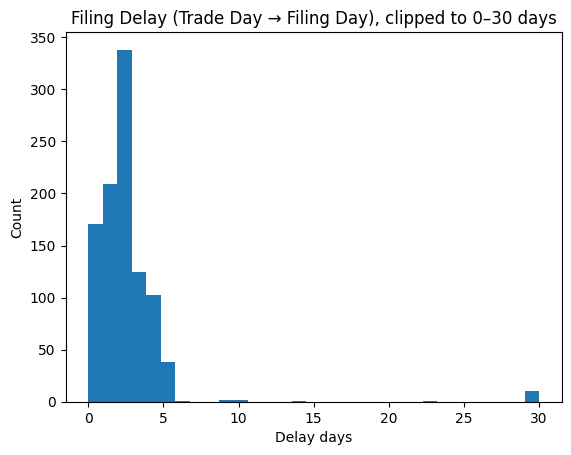

Signal trades count: 248
Other trades count: 752
Signal delay (median): 0.0
Other delay (median): 2.0


In [11]:
ins["filing_delay_days"] = (ins["filing_day"] - ins["trade_day"]).dt.days

plt.figure()
plt.hist(ins["filing_delay_days"].clip(lower=0, upper=30), bins=31)
plt.title("Filing Delay (Trade Day → Filing Day), clipped to 0–30 days")
plt.xlabel("Delay days")
plt.ylabel("Count")
plt.show()

# Compare delay distributions for signal vs non-signal
BUY_TYPES = ["P"]
SELL_TYPES = ["S","S+OE","D"]

ins["is_signal"] = ins["trade_type"].isin(BUY_TYPES + SELL_TYPES)

delay_signal = ins.loc[ins["is_signal"], "filing_delay_days"]
delay_other  = ins.loc[~ins["is_signal"], "filing_delay_days"]

print("Signal trades count:", delay_signal.shape[0])
print("Other trades count:", delay_other.shape[0])

print("Signal delay (median):", float(delay_signal.median()))
print("Other delay (median):", float(delay_other.median()))

In [12]:
ins_sig = ins[ins["trade_type"].isin(BUY_TYPES + SELL_TYPES)].copy()

print("Signal trades rows:", len(ins_sig))
print("Signal trade types:")
display(ins_sig["trade_type"].value_counts())

ins_sig["is_buy"]  = ins_sig["trade_type"].isin(BUY_TYPES)
ins_sig["is_sell"] = ins_sig["trade_type"].isin(SELL_TYPES)

def sum_pos(s): return s[s > 0].sum()
def sum_neg_abs(s): return (-s[s < 0]).sum()

daily = ins_sig.groupby("event_day").agg(
    n_trades=("trade_type", "size"),
    n_buy=("is_buy", "sum"),
    n_sell=("is_sell", "sum"),
    net_value=("trade_value", "sum"),
    buy_value=("trade_value", sum_pos),
    sell_value=("trade_value", sum_neg_abs),
    net_shares=("qty", "sum"),
    unique_insiders=("insider_name", "nunique"),
).reset_index().sort_values("event_day").reset_index(drop=True)

print("Daily event rows:", daily.shape)
display(daily.head(10))

Signal trades rows: 248
Signal trade types:


,count
trade_type,
S,158
S+OE,67
P,22
D,1


Daily event rows: (114, 9)


,event_day,n_trades,n_buy,n_sell,net_value,buy_value,sell_value,net_shares,unique_insiders
0,2015-01-16,6,0,6,-4043238.0,0.0,4043238.0,-73026.0,6
1,2015-01-20,1,1,0,498384.0,498384.0,0.0,9050.0,1
2,2015-01-26,4,0,4,-13293797.0,0.0,13293797.0,-233548.0,4
3,2015-02-18,1,0,1,-169598.0,0.0,169598.0,-2826.0,1
4,2015-04-16,2,0,2,-1465926.0,0.0,1465926.0,-22875.0,2
5,2015-07-16,4,0,4,-5784458.0,0.0,5784458.0,-83748.0,4
6,2015-10-15,1,0,1,-437532.0,0.0,437532.0,-7217.0,1
7,2015-10-23,1,0,1,-415124.0,0.0,415124.0,-400.0,1
8,2015-10-27,1,0,1,-72846.0,0.0,72846.0,-1144.0,1
9,2015-11-02,1,1,0,50452.0,50452.0,0.0,800.0,1


In [13]:
master = px.copy()
master["day"] = master["date"].dt.normalize()

master = master.merge(daily, left_on="day", right_on="event_day", how="left")

for col in ["n_trades","n_buy","n_sell","net_value","buy_value","sell_value","net_shares","unique_insiders"]:
    master[col] = master[col].fillna(0)

# Assert no row duplication
assert master.shape[0] == px.shape[0], "Merge changed number of trading-day rows."

display(master[["date","price","n_trades","net_value","unique_insiders"]].head(15))

,date,price,n_trades,net_value,unique_insiders
0,2015-01-02,62.49,0.0,0.0,0.0
1,2015-01-05,60.55,0.0,0.0,0.0
2,2015-01-06,58.98,0.0,0.0,0.0
3,2015-01-07,59.07,0.0,0.0,0.0
4,2015-01-08,60.39,0.0,0.0,0.0
5,2015-01-09,59.34,0.0,0.0,0.0
6,2015-01-12,58.83,0.0,0.0,0.0
7,2015-01-13,58.84,0.0,0.0,0.0
8,2015-01-14,56.81,0.0,0.0,0.0
9,2015-01-15,54.99,0.0,0.0,0.0


In [14]:
master = master.sort_values("date").reset_index(drop=True)

# Core returns
master["ret_cc_1d"] = master["price"].pct_change()                      # close-to-close
master["ret_oc"]    = (master["price"] / master["open"]) - 1            # open-to-close (intraday)
master["prev_close"] = master["price"].shift(1)

# Event-day "reaction" returns (these are key for event study)
master["ret_prevclose_to_close"] = (master["price"] / master["prev_close"]) - 1  # includes overnight + intraday
master["ret_prevclose_to_open"]  = (master["open"]  / master["prev_close"]) - 1  # overnight gap
master["ret_open_to_close"]      = (master["price"] / master["open"]) - 1        # intraday move

# Forward returns from event_day close (post-event drift)
def fwd_return_from_close(i, h):
    j = i + h
    if i < 0 or j >= len(master): return np.nan
    return (master.loc[j, "price"] / master.loc[i, "price"]) - 1

# Map day->row index
day_to_i = {d: i for i, d in enumerate(master["day"])}

def fwd_return_day(day, h):
    i = day_to_i.get(pd.Timestamp(day))
    if i is None: return np.nan
    return fwd_return_from_close(i, h)

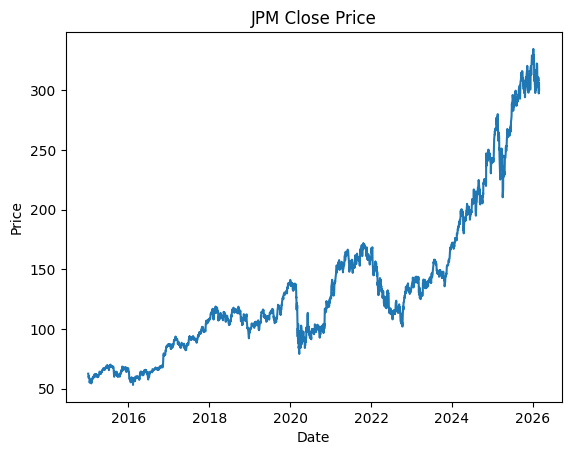

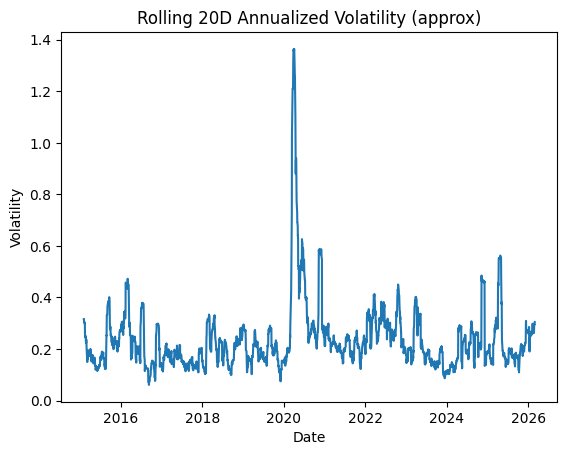

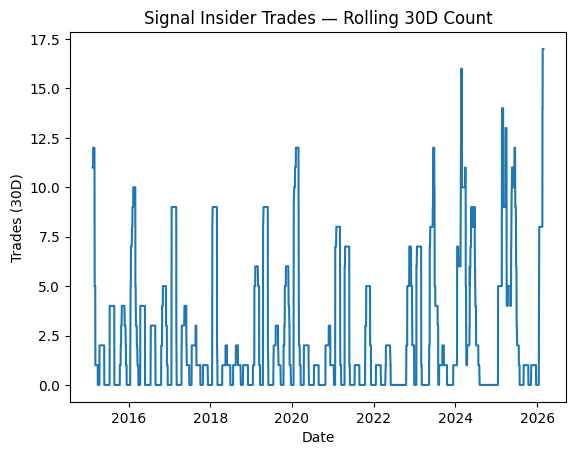

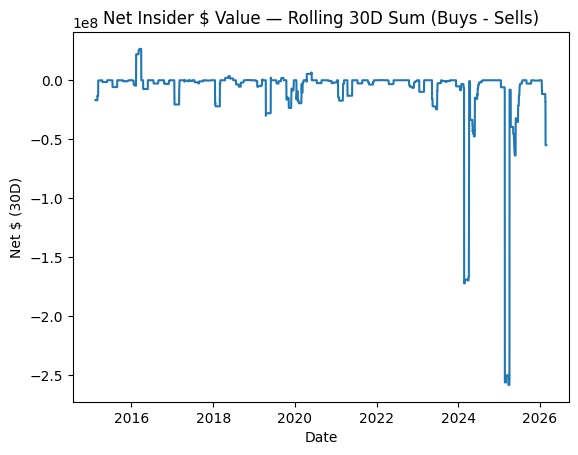

In [15]:
master["vol_20d_ann"] = master["ret_cc_1d"].rolling(20).std() * np.sqrt(252)

plt.figure()
plt.plot(master["date"], master["price"])
plt.title("JPM Close Price")
plt.xlabel("Date"); plt.ylabel("Price")
plt.show()

plt.figure()
plt.plot(master["date"], master["vol_20d_ann"])
plt.title("Rolling 20D Annualized Volatility (approx)")
plt.xlabel("Date"); plt.ylabel("Volatility")
plt.show()

# Insider rolling metrics (signal-only events)
master["net_value_30d"] = master["net_value"].rolling(30).sum()
master["trades_30d"] = master["n_trades"].rolling(30).sum()
master["unique_insiders_30d"] = master["unique_insiders"].rolling(30).sum()

plt.figure()
plt.plot(master["date"], master["trades_30d"])
plt.title("Signal Insider Trades — Rolling 30D Count")
plt.xlabel("Date"); plt.ylabel("Trades (30D)")
plt.show()

plt.figure()
plt.plot(master["date"], master["net_value_30d"])
plt.title("Net Insider $ Value — Rolling 30D Sum (Buys - Sells)")
plt.xlabel("Date"); plt.ylabel("Net $ (30D)")
plt.show()

In [16]:
events = daily.copy()
events["i"] = events["event_day"].map(day_to_i)

# Reaction metrics on event day (corrected)
events["reaction_prevclose_to_close"] = events["event_day"].map(
    lambda d: master.loc[day_to_i[d], "ret_prevclose_to_close"] if d in day_to_i else np.nan
)
events["reaction_prevclose_to_open"] = events["event_day"].map(
    lambda d: master.loc[day_to_i[d], "ret_prevclose_to_open"] if d in day_to_i else np.nan
)
events["reaction_open_to_close"] = events["event_day"].map(
    lambda d: master.loc[day_to_i[d], "ret_open_to_close"] if d in day_to_i else np.nan
)

# Post-event drift from event_day close
events["drift_1d"]  = events["event_day"].apply(lambda d: fwd_return_day(d, 1))
events["drift_5d"]  = events["event_day"].apply(lambda d: fwd_return_day(d, 5))
events["drift_20d"] = events["event_day"].apply(lambda d: fwd_return_day(d, 20))

events["net_side"] = np.where(events["net_value"] > 0, "BUY_DOM", "SELL_DOM")
events["abs_net_value"] = events["net_value"].abs()

display(events.head(10))

,event_day,n_trades,n_buy,n_sell,net_value,buy_value,sell_value,net_shares,unique_insiders,i,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_1d,drift_5d,drift_20d,net_side,abs_net_value
0,2015-01-16,6,0,6,-4043238.0,0.0,4043238.0,-73026.0,6,10,0.017094,-0.006001,0.023235,-0.003933,0.015019,0.074557,SELL_DOM,4043238.0
1,2015-01-20,1,1,0,498384.0,498384.0,0.0,9050.0,1,11,-0.003933,0.001967,-0.005889,0.003231,0.008796,0.065697,BUY_DOM,498384.0
2,2015-01-26,4,0,4,-13293797.0,0.0,13293797.0,-233548.0,4,15,0.001588,-0.004764,0.006382,-0.010041,-0.022899,0.071340,SELL_DOM,13293797.0
3,2015-02-18,1,0,1,-169598.0,0.0,169598.0,-2826.0,1,31,-0.012146,-0.005158,-0.007025,-0.002358,0.029813,0.040088,SELL_DOM,169598.0
4,2015-04-16,2,0,2,-1465926.0,0.0,1465926.0,-22875.0,2,71,-0.006230,-0.002025,-0.004213,-0.015201,-0.015828,0.035104,SELL_DOM,1465926.0
5,2015-07-16,4,0,4,-5784458.0,0.0,5784458.0,-83748.0,4,134,0.005348,0.006359,-0.001005,-0.005032,0.001150,-0.028896,SELL_DOM,5784458.0
6,2015-10-15,1,0,1,-437532.0,0.0,437532.0,-7217.0,1,198,0.031672,0.008001,0.023483,0.008725,0.021005,0.066408,SELL_DOM,437532.0
7,2015-10-23,1,0,1,-415124.0,0.0,415124.0,-400.0,1,204,0.010761,0.006963,0.003772,0.000470,0.005950,0.057460,SELL_DOM,415124.0
8,2015-10-27,1,0,1,-72846.0,0.0,72846.0,-1144.0,1,206,-0.004069,-0.005790,0.001731,0.029227,0.033627,0.049340,SELL_DOM,72846.0
9,2015-11-02,1,1,0,50452.0,50452.0,0.0,800.0,1,210,0.020078,0.003113,0.016912,0.003662,0.028227,0.031584,BUY_DOM,50452.0


In [17]:
summary = events.groupby("net_side")[[
    "reaction_prevclose_to_close",
    "reaction_prevclose_to_open",
    "reaction_open_to_close",
    "drift_1d","drift_5d","drift_20d"
]].agg(["mean","median","count"]).round(6)

display(summary)

# Top 10 largest events for narrative
display(
    events.sort_values("abs_net_value", ascending=False).head(10)[
        ["event_day","n_trades","n_buy","n_sell","net_value","unique_insiders",
         "reaction_prevclose_to_close","drift_5d","drift_20d"]
    ]
)

reaction_prevclose_to_close                  \
                                mean    median count   
net_side                                               
BUY_DOM                     0.004531 -0.003933    21   
SELL_DOM                    0.000255  0.001588    93   

         reaction_prevclose_to_open                 reaction_open_to_close  \
                               mean    median count                   mean   
net_side                                                                     
BUY_DOM                    0.004624  0.001967    21              -0.000257   
SELL_DOM                   0.000058  0.000037    93               0.000193   

                          drift_1d                  drift_5d                  \
            median count      mean    median count      mean    median count   
net_side                                                                       
BUY_DOM  -0.005889    21 -0.000935  0.001232    21  0.007750  0.008902    21   
SELL_DOM  0.001468    93  0.001045 -0.001317    93  0.007662  0.005950    93   

         drift_20d                  
              mean    median count  
net_side                            
BUY_DOM   0.023949  0.028353    21  
SELL_DOM  0.028018  0.028446    91

,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,drift_5d,drift_20d
98,2025-02-21,5,0,5,-245940124.0,5,-0.009595,0.001552,-0.085566
86,2024-02-23,4,0,4,-165690610.0,4,0.005025,0.007066,0.068645
113,2026-02-20,3,0,3,-36841915.0,3,0.008895,-0.033753,NaN
88,2024-04-16,1,0,1,-32824625.0,1,-0.011428,0.062721,0.114546
100,2025-04-15,1,0,1,-31495692.0,1,-0.006774,0.033243,0.139450
40,2019-04-17,7,0,7,-30154695.0,7,0.028803,-0.006037,-0.026159
14,2016-02-12,1,1,0,26590517.0,1,0.083286,0.018786,0.028353
29,2018-01-18,7,0,7,-19939217.0,7,0.002390,0.021543,0.019866
46,2019-10-18,2,0,2,-16380073.0,2,0.001745,0.045372,0.074403
50,2020-01-16,8,0,8,-16319483.0,8,0.003877,-0.029872,0.001530


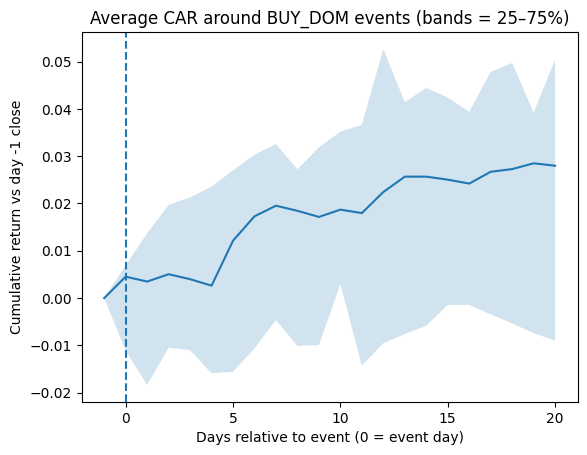

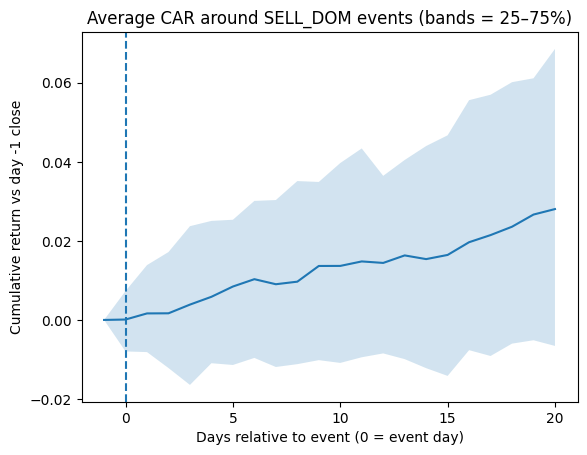

In [18]:
PRE_DAYS = 1
POST_DAYS = 20

def car_matrix(event_days):
    """
    Returns matrix shape: [n_events, PRE_DAYS+POST_DAYS+1]
    CAR baseline = close at day -1 (prev trading day close)
    Points represent cumulative return up to each relative day.
    """
    rel = np.arange(-PRE_DAYS, POST_DAYS + 1)
    rows = []
    for d in event_days:
        i = day_to_i.get(pd.Timestamp(d))
        if i is None:
            continue
        if i - PRE_DAYS < 0 or i + POST_DAYS >= len(master):
            continue
        base = master.loc[i - 1, "price"]  # day -1 close
        path = master.loc[i - PRE_DAYS : i + POST_DAYS, "price"].values
        car = (path / base) - 1
        rows.append(car)
    if len(rows) == 0:
        return rel, np.empty((0, len(rel)))
    return rel, np.vstack(rows)

def plot_car(rel, mat, title):
    if mat.shape[0] == 0:
        print("No events available for:", title)
        return
    mean = np.nanmean(mat, axis=0)
    q25  = np.nanquantile(mat, 0.25, axis=0)
    q75  = np.nanquantile(mat, 0.75, axis=0)

    plt.figure()
    plt.plot(rel, mean)
    plt.fill_between(rel, q25, q75, alpha=0.2)
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("Days relative to event (0 = event day)")
    plt.ylabel("Cumulative return vs day -1 close")
    plt.show()

buy_days  = events.loc[events["net_side"]=="BUY_DOM", "event_day"].tolist()
sell_days = events.loc[events["net_side"]=="SELL_DOM","event_day"].tolist()

rel, buy_mat  = car_matrix(buy_days)
_,   sell_mat = car_matrix(sell_days)

plot_car(rel, buy_mat,  "Average CAR around BUY_DOM events (bands = 25–75%)")
plot_car(rel, sell_mat, "Average CAR around SELL_DOM events (bands = 25–75%)")

/tmp/ipykernel_151/4156354469.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


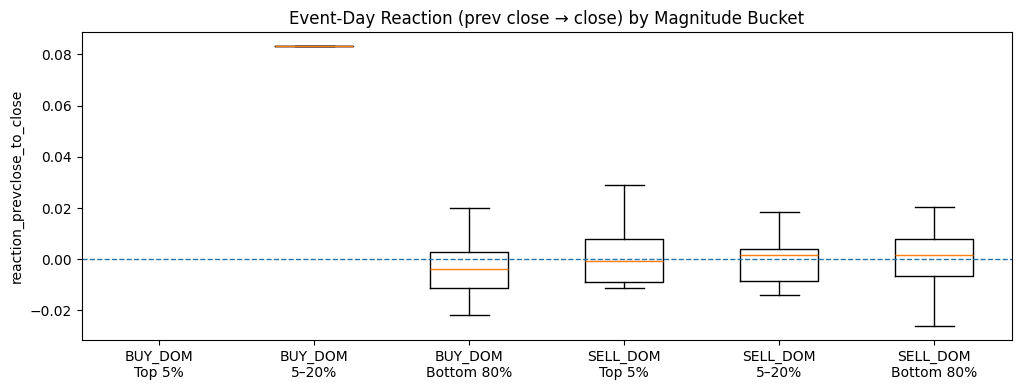

/tmp/ipykernel_151/4156354469.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


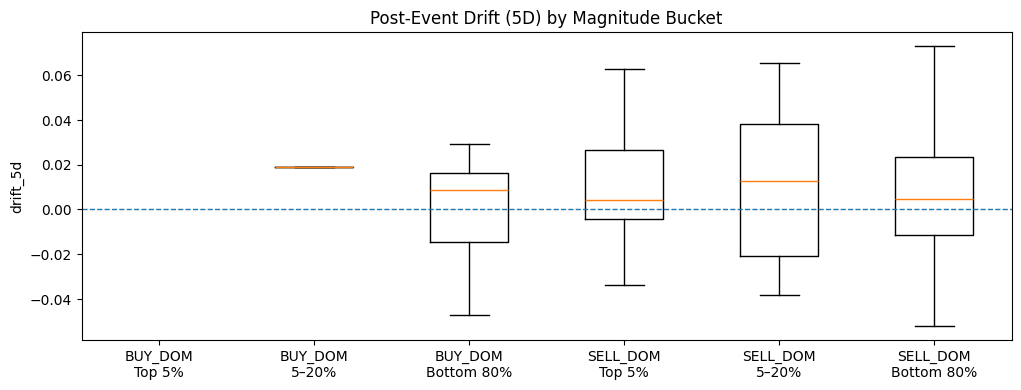

In [19]:
# Bucket by absolute net value percentiles (top 5%, 5–20%, rest)
q95 = events["abs_net_value"].quantile(0.95)
q80 = events["abs_net_value"].quantile(0.80)

def bucket(v):
    if v >= q95: return "Top 5%"
    if v >= q80: return "5–20%"
    return "Bottom 80%"

events["mag_bucket"] = events["abs_net_value"].apply(bucket)

# Boxplot drift_5d by bucket and side
def boxplot_by(group_col, value_col, title):
    groups = []
    labels = []
    for side in ["BUY_DOM", "SELL_DOM"]:
        for b in ["Top 5%","5–20%","Bottom 80%"]:
            vals = events.loc[(events["net_side"]==side) & (events[group_col]==b), value_col].dropna().values
            groups.append(vals)
            labels.append(f"{side}\n{b}")
    plt.figure(figsize=(12,4))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.ylabel(value_col)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.show()

boxplot_by("mag_bucket", "reaction_prevclose_to_close", "Event-Day Reaction (prev close → close) by Magnitude Bucket")
boxplot_by("mag_bucket", "drift_5d", "Post-Event Drift (5D) by Magnitude Bucket")

In [20]:
# Define volatility regimes by terciles
vol = master["vol_20d_ann"].dropna()
v1, v2 = vol.quantile([0.33, 0.66]).values

def vol_regime(x):
    if np.isnan(x): return "NA"
    if x <= v1: return "LowVol"
    if x <= v2: return "MidVol"
    return "HighVol"

master["vol_regime"] = master["vol_20d_ann"].apply(vol_regime)

# Attach regime to events
events["vol_regime"] = events["event_day"].map(lambda d: master.loc[day_to_i[d], "vol_regime"])

reg_summary = events.groupby(["net_side","vol_regime"])[
    ["reaction_prevclose_to_close","drift_5d","drift_20d"]
].agg(["mean","median","count"]).round(6)

display(reg_summary)

reaction_prevclose_to_close                  drift_5d  \
                                           mean    median count      mean   
net_side vol_regime                                                         
BUY_DOM  HighVol                       0.021525 -0.007712     6 -0.001184   
         LowVol                       -0.005428 -0.004368     7  0.014627   
         MidVol                        0.001132  0.001234     7  0.008381   
         NA                           -0.003933 -0.003933     1  0.008796   
SELL_DOM HighVol                      -0.002228 -0.002282    30  0.018585   
         LowVol                        0.000599  0.001447    31  0.006705   
         MidVol                        0.001779  0.003100    30 -0.001498   
         NA                            0.009341  0.009341     2 -0.003940   

                                    drift_20d                  
                       median count      mean    median count  
net_side vol_regime                                            
BUY_DOM  HighVol     0.007515     6  0.005084  0.032563     6  
         LowVol      0.000391     7  0.022681  0.004750     7  
         MidVol      0.013550     7  0.035424  0.037769     7  
         NA          0.008796     1  0.065697  0.065697     1  
SELL_DOM HighVol     0.022297    30  0.053374  0.028591    28  
         LowVol      0.007066    31  0.025029  0.019866    31  
         MidVol      0.001550    30  0.004444  0.018530    30  
         NA         -0.003940     2  0.072949  0.072949     2

In [21]:
def role_bucket(title):
    t = str(title).lower()
    if "ceo" in t or "cob" in t or "chief executive" in t:
        return "CEO/COB"
    if "cfo" in t or "chief financial" in t:
        return "CFO"
    if "co-ceo" in t or "co ceo" in t:
        return "Co-CEO"
    if "dir" in t or "director" in t:
        return "Director"
    if "vp" in t or "vice president" in t:
        return "VP"
    if "chief" in t:
        return "Other Chief"
    return "Other"

ins_sig["role_bucket"] = ins_sig["insider_title"].apply(role_bucket)

# Aggregate role impact per event day
role_daily = ins_sig.groupby(["event_day","role_bucket"]).agg(
    role_net_value=("trade_value","sum"),
    role_trades=("trade_value","size"),
    role_unique=("insider_name","nunique"),
).reset_index()

# Focus on top roles by total absolute value
top_roles = (role_daily.groupby("role_bucket")["role_net_value"]
             .apply(lambda s: s.abs().sum())
             .sort_values(ascending=False)
             .head(8)
             .index.tolist())

role_daily_top = role_daily[role_daily["role_bucket"].isin(top_roles)].copy()

display(role_daily_top.head(10))

# Role vs event-day reaction (merge role stats into events)
role_pivot = role_daily_top.pivot_table(index="event_day", columns="role_bucket", values="role_net_value", aggfunc="sum").fillna(0)
role_pivot = role_pivot.reset_index()

events_role = events.merge(role_pivot, on="event_day", how="left").fillna(0)

# Simple correlation snapshot: which roles relate to reaction?
corr_cols = ["reaction_prevclose_to_close"] + top_roles
corr = events_role[corr_cols].corr(numeric_only=True)["reaction_prevclose_to_close"].sort_values(ascending=False)
display(corr)

,event_day,role_bucket,role_net_value,role_trades,role_unique
0,2015-01-16,Director,-298680.0,1,1
1,2015-01-16,Other,-3475535.0,4,4
2,2015-01-16,Other Chief,-269023.0,1,1
3,2015-01-20,Director,498384.0,1,1
4,2015-01-26,Other,-11629538.0,3,3
5,2015-01-26,VP,-1664259.0,1,1
6,2015-02-18,CFO,-169598.0,1,1
7,2015-04-16,Other,-1465926.0,2,2
8,2015-07-16,CFO,-2242532.0,1,1
9,2015-07-16,Other,-1270773.0,2,2


,reaction_prevclose_to_close
reaction_prevclose_to_close,1.000000
Director,0.316384
CEO/COB,0.078834
Other,0.054334
VP,-0.013450
Other Chief,-0.027795
CFO,-0.100372


In [22]:
# Build per-insider event outcomes (based on event_day)
# We compute per event-day outcomes once, then attribute that event to insiders who traded that day.

# Insider-day table: which insiders traded on which event_day, with their net_value that day
insider_day = ins_sig.groupby(["event_day","insider_name","insider_title"]).agg(
    insider_net_value=("trade_value","sum"),
    insider_trades=("trade_value","size")
).reset_index()

# Merge event outcomes
insider_day = insider_day.merge(
    events[["event_day","reaction_prevclose_to_close","drift_5d","drift_20d"]],
    on="event_day",
    how="left"
)

# Keep insiders with >= 5 event days (avoid tiny-sample noise)
insider_counts = insider_day.groupby("insider_name")["event_day"].nunique().sort_values(ascending=False)
keep_insiders = insider_counts[insider_counts >= 5].index.tolist()

insider_summary = insider_day[insider_day["insider_name"].isin(keep_insiders)].groupby("insider_name").agg(
    n_event_days=("event_day","nunique"),
    median_reaction=("reaction_prevclose_to_close","median"),
    median_drift_5d=("drift_5d","median"),
    median_drift_20d=("drift_20d","median"),
    total_abs_value=("insider_net_value", lambda s: s.abs().sum())
).sort_values("total_abs_value", ascending=False)

display(insider_summary.head(15))

,n_event_days,median_reaction,median_drift_5d,median_drift_20d,total_abs_value
insider_name,,,,,
Dimon James,7,0.005025,0.018786,0.050114,496258581.0
Erdoes Mary E.,25,0.002808,-0.008027,0.037116,69447296.0
Rohrbaugh Troy L,5,0.008895,0.001552,-0.010636,48643623.0
Lake Marianne,22,0.002684,0.006480,0.020405,45497756.0
Pinto Daniel E,7,0.001588,0.033942,0.051454,42553330.0
Petno Douglas B,24,0.003150,0.015408,0.052940,38793063.0
Smith Gordon,9,0.001745,-0.001407,0.027517,36332400.0
Bacon Ashley,23,0.003877,0.001228,0.027517,32816959.0
Friedman Stacey,22,0.000871,-0.005530,0.019951,24844742.0


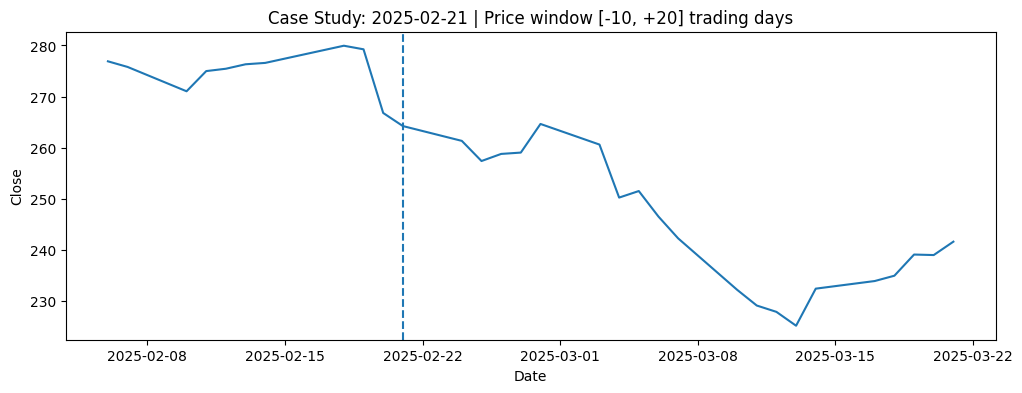

,filing_date,trade_date,insider_name,insider_title,trade_type,qty,trade_price,trade_value
98,2025-02-20 18:41:23,2025-02-20,Leopold Robin,Head of HR,S,-1250.0,270.09,-337610.0
96,2025-02-20 18:49:34,2025-02-20,Beer Lori A,CIO,S,-2053.0,269.88,-554054.0
97,2025-02-20 18:43:26,2025-02-20,Piepszak Jennifer,COO,S,-4273.0,269.85,-1153078.0
95,2025-02-20 18:51:38,2025-02-20,Rohrbaugh Troy L,Co-CEO CIB,S,-37500.0,269.84,-10118869.0
99,2025-02-20 18:21:49,2025-02-20,Dimon James,"COB, CEO",S,-866361.0,269.84,-233776513.0


,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_5d,drift_20d
98,2025-02-21,5,0,5,-245940124.0,5,-0.009595,0.005697,-0.015206,0.001552,-0.085566


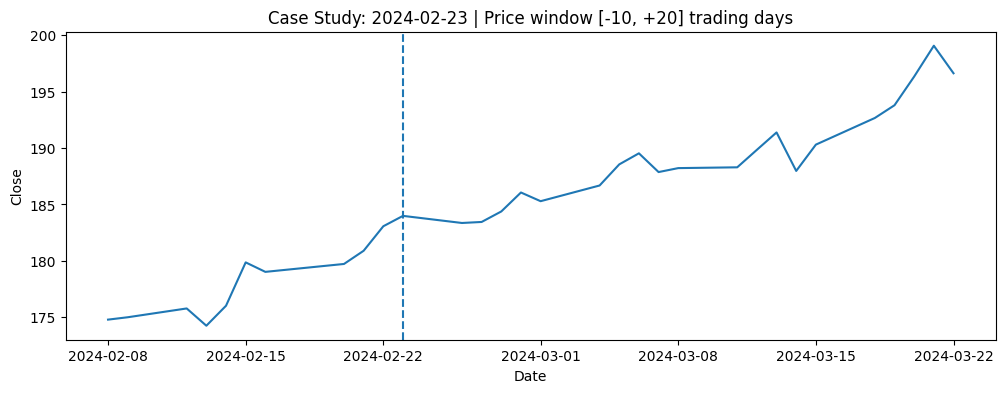

,filing_date,trade_date,insider_name,insider_title,trade_type,qty,trade_price,trade_value
186,2024-02-22 18:51:40,2024-02-22,Beer Lori A,CIO,S,-3920.0,182.74,-716356.0
187,2024-02-22 18:51:32,2024-02-22,Friedman Stacey,GC,S,-6030.0,182.73,-1101878.0
185,2024-02-22 18:51:41,2024-02-22,Rohrbaugh Troy L,"Co-CEO Comm., Invest. Bank",S,-75000.0,182.74,-13705155.0
188,2024-02-22 17:51:39,2024-02-22,Dimon James,"COB, CEO",S,-821778.0,182.74,-150167221.0


,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_5d,drift_20d
86,2024-02-23,4,0,4,-165690610.0,4,0.005025,0.004042,0.000979,0.007066,0.068645


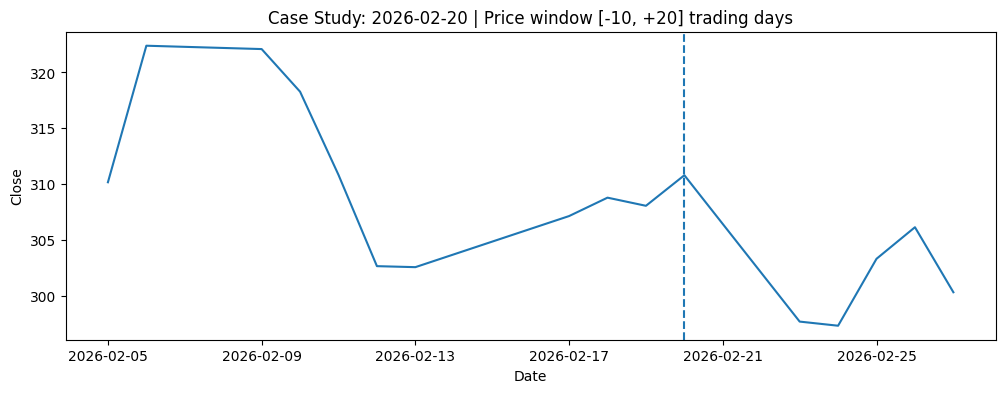

,filing_date,trade_date,insider_name,insider_title,trade_type,qty,trade_price,trade_value
0,2026-02-19 17:36:59,2026-02-19,Leopold Robin,Head of HR,S,-432.0,307.14,-132684.0
1,2026-02-19 17:33:57,2026-02-19,Rohrbaugh Troy L,Co-CEO CIB,S,-50000.0,307.11,-15355670.0
2,2026-02-19 17:19:53,2026-02-19,Dimon James,"COB, CEO",S,-69512.0,307.19,-21353561.0


,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_5d,drift_20d
113,2026-02-20,3,0,3,-36841915.0,3,0.008895,0.001136,0.00775,-0.033753,NaN


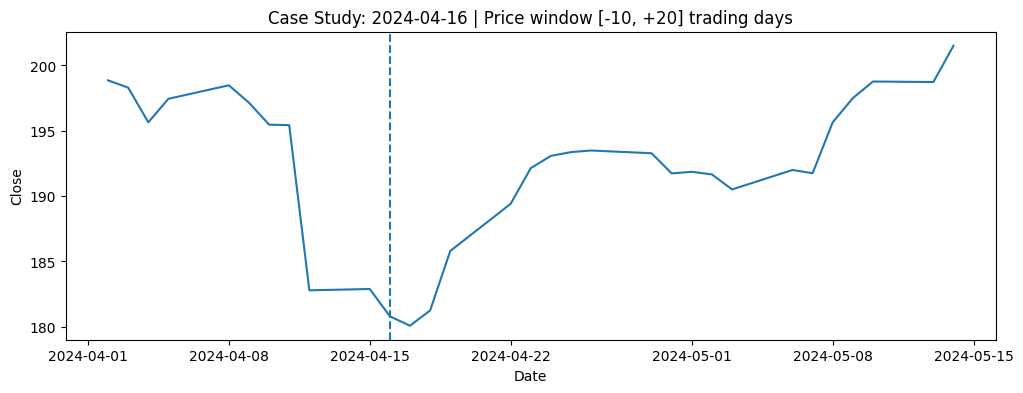

,filing_date,trade_date,insider_name,insider_title,trade_type,qty,trade_price,trade_value
165,2024-04-15 16:56:52,2024-04-15,Dimon James,"COB, CEO",S,-178222.0,184.18,-32824625.0


,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_5d,drift_20d
88,2024-04-16,1,0,1,-32824625.0,1,-0.011428,0.000055,-0.011482,0.062721,0.114546


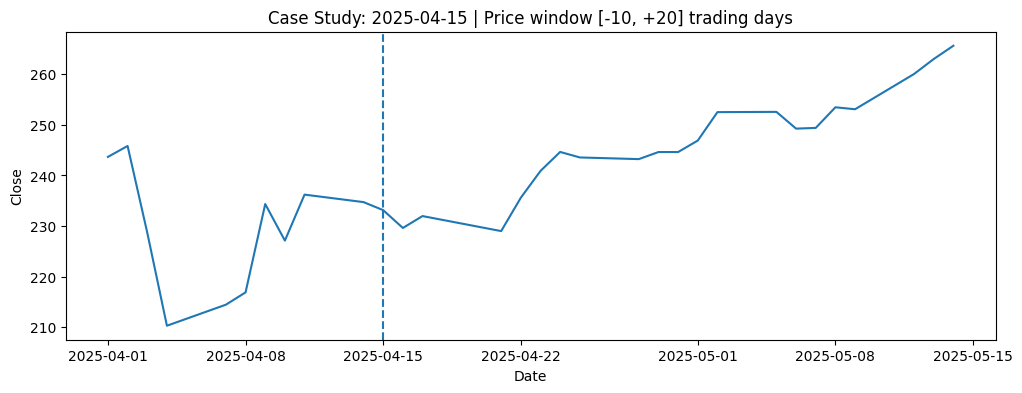

,filing_date,trade_date,insider_name,insider_title,trade_type,qty,trade_price,trade_value
74,2025-04-14 17:47:55,2025-04-14,Dimon James,"COB, CEO",S,-133639.0,235.68,-31495692.0


,event_day,n_trades,n_buy,n_sell,net_value,unique_insiders,reaction_prevclose_to_close,reaction_prevclose_to_open,reaction_open_to_close,drift_5d,drift_20d
100,2025-04-15,1,0,1,-31495692.0,1,-0.006774,0.005879,-0.012579,0.033243,0.13945


In [23]:
TOP_K = 5
top_events = events.sort_values("abs_net_value", ascending=False).head(TOP_K)

def plot_case(event_day, window_before=10, window_after=20):
    i = day_to_i[pd.Timestamp(event_day)]
    i0 = max(0, i - window_before)
    i1 = min(len(master)-1, i + window_after)

    sub = master.loc[i0:i1].copy()

    plt.figure(figsize=(12,4))
    plt.plot(sub["date"], sub["price"])
    plt.axvline(master.loc[i, "date"], linestyle="--")
    plt.title(f"Case Study: {event_day.date()} | Price window [-{window_before}, +{window_after}] trading days")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.show()

    # Trades that contributed to this event
    trades = ins_sig[ins_sig["event_day"] == pd.Timestamp(event_day)].copy()
    trades = trades.sort_values("trade_value", ascending=False)

    display(trades[["filing_date","trade_date","insider_name","insider_title","trade_type","qty","trade_price","trade_value"]].head(25))

    # Event outcome row
    display(events[events["event_day"] == pd.Timestamp(event_day)][
        ["event_day","n_trades","n_buy","n_sell","net_value","unique_insiders",
         "reaction_prevclose_to_close","reaction_prevclose_to_open","reaction_open_to_close",
         "drift_5d","drift_20d"]
    ])

for d in top_events["event_day"].tolist():
    plot_case(pd.Timestamp(d))

In [24]:
# Plotly makes candlesticks easy and looks modern in portfolios
!pip -q install plotly
import plotly.graph_objects as go

# Choose a recent window for readability (last ~2 years)
END_DATE = master["date"].max()
START_DATE = END_DATE - pd.Timedelta(days=365*2)

sub = master[(master["date"] >= START_DATE) & (master["date"] <= END_DATE)].copy()

# Event markers in the same window
ev_sub = events[(events["event_day"] >= sub["day"].min()) & (events["event_day"] <= sub["day"].max())].copy()

fig = go.Figure(data=[
    go.Candlestick(
        x=sub["date"],
        open=sub["open"],
        high=sub["high"],
        low=sub["low"],
        close=sub["price"],
        name="JPM"
    )
])

# Marker size based on abs net value (scaled)
if len(ev_sub) > 0:
    sizes = 6 + 18 * (ev_sub["abs_net_value"] / ev_sub["abs_net_value"].max()).fillna(0)
    colors = np.where(ev_sub["net_value"] > 0, "green", "red")

    fig.add_trace(go.Scatter(
        x=pd.to_datetime(ev_sub["event_day"]),
        y=[sub.set_index("day").loc[d, "price"] if d in set(sub["day"]) else None for d in ev_sub["event_day"]],
        mode="markers",
        marker=dict(size=sizes, color=colors, opacity=0.7),
        name="Insider event days (size ~ magnitude)"
    ))

fig.update_layout(
    title="JPM Candlestick with Insider Event Days Overlay (size ~ abs net value)",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    height=550
)
fig.show()

In [26]:
# Plotly makes candlesticks easy and looks modern in portfolios
!pip -q install plotly
import plotly.graph_objects as go

# Choose a recent window for readability (last ~2 years)
END_DATE = master["date"].max()
START_DATE = END_DATE - pd.Timedelta(days=365*2)

sub = master[(master["date"] >= START_DATE) & (master["date"] <= END_DATE)].copy()

# Event markers in the same window
ev_sub = events[(events["event_day"] >= sub["day"].min()) & (events["event_day"] <= sub["day"].max())].copy()

# --- NEW: build "which insider event is it?" text per event_day ---
# Make a compact summary of insiders involved on that event_day (top 5 by abs value)
tmp = ins_sig.copy()
tmp["abs_value"] = tmp["trade_value"].abs()

def format_trade_row(r):
    # Example: "Dimon James (COB, CEO) S  -$21.35M"
    val_m = r["trade_value"] / 1e6
    sign = "+" if val_m >= 0 else "-"
    return f'{r["insider_name"]} ({r["insider_title"]}) {r["trade_type"]}  {sign}${abs(val_m):.2f}M'

day_summaries = []
for day, g in tmp.groupby("event_day"):
    g = g.sort_values("abs_value", ascending=False)
    top = g.head(5)

    lines = [format_trade_row(r) for _, r in top.iterrows()]
    more = len(g) - len(top)
    if more > 0:
        lines.append(f"... +{more} more trade(s)")

    day_summaries.append({
        "event_day": day,
        "event_label": "<br>".join(lines)  # <br> renders as new line in hover
    })

event_label_df = pd.DataFrame(day_summaries)

# Merge label into ev_sub
ev_sub = ev_sub.merge(event_label_df, on="event_day", how="left")
ev_sub["event_label"] = ev_sub["event_label"].fillna("No insider detail available")

# Build y-values for markers (price on that day)
sub_day_price = sub.set_index("day")["price"]
ev_sub["marker_y"] = ev_sub["event_day"].map(lambda d: sub_day_price.get(d, np.nan))

fig = go.Figure(data=[
    go.Candlestick(
        x=sub["date"],
        open=sub["open"],
        high=sub["high"],
        low=sub["low"],
        close=sub["price"],
        name="JPM"
    )
])

# Marker size based on abs net value (scaled)
if len(ev_sub) > 0:
    sizes = 6 + 18 * (ev_sub["abs_net_value"] / ev_sub["abs_net_value"].max()).fillna(0)
    colors = np.where(ev_sub["net_value"] > 0, "green", "red")

    # Hover details: day-level + top insider trades
    hover = (
        "<b>Event day:</b> %{x|%Y-%m-%d}<br>"
        "<b>Net side:</b> %{customdata[0]}<br>"
        "<b>Net value:</b> %{customdata[1]:,.0f}<br>"
        "<b>Trades:</b> %{customdata[2]} (Buy %{customdata[3]}, Sell %{customdata[4]})<br>"
        "<b>Unique insiders:</b> %{customdata[5]}<br>"
        "<br><b>Top insider trades:</b><br>%{customdata[6]}<extra></extra>"
    )

    fig.add_trace(go.Scatter(
        x=pd.to_datetime(ev_sub["event_day"]),
        y=ev_sub["marker_y"],
        mode="markers",
        marker=dict(size=sizes, color=colors, opacity=0.7),
        name="Insider event days (size ~ magnitude)",
        customdata=np.stack([
            ev_sub["net_side"].values,
            ev_sub["net_value"].values,
            ev_sub["n_trades"].values,
            ev_sub["n_buy"].values,
            ev_sub["n_sell"].values,
            ev_sub["unique_insiders"].values,
            ev_sub["event_label"].values
        ], axis=1),
        hovertemplate=hover
    ))

fig.update_layout(
    title="JPM Candlestick with Insider Event Days Overlay (hover shows insiders & trades)",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    height=600
)
fig.show()

In [25]:
OUT_DIR = os.path.join(PROJECT_DIR, "eda_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

master_out = os.path.join(OUT_DIR, "master_daily_event_aligned.csv")
events_out = os.path.join(OUT_DIR, "event_study_table.csv")
ins_sig_out = os.path.join(OUT_DIR, "insider_signal_with_event_day.csv")
insider_summary_out = os.path.join(OUT_DIR, "insider_summary_min5events.csv")

master.to_csv(master_out, index=False)
events.to_csv(events_out, index=False)
ins_sig.to_csv(ins_sig_out, index=False)
insider_summary.reset_index().to_csv(insider_summary_out, index=False)

print(" Saved:", master_out)
print(" Saved:", events_out)
print(" Saved:", ins_sig_out)
print(" Saved:", insider_summary_out)

 Saved: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/eda_outputs/master_daily_event_aligned.csv
 Saved: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/eda_outputs/event_study_table.csv
 Saved: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/eda_outputs/insider_signal_with_event_day.csv
 Saved: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/eda_outputs/insider_summary_min5events.csv
